## Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from IPython import display

## Inspect Data Structures

In [ ]:
file_path = 'Clinical-QA-NLP/backend/AI/data/raw/pubmedqa_unlabeled_raw.csv'

dagshub_url = 'https://dagshub.com/THoangHa/Clinical-QA-System/raw/main/backend/AI/data/raw/pubmedqa_unlabeled_raw.csv'

df = pd.read_csv(dagshub_url)
df.head()

KeyboardInterrupt: 

In [ ]:
# Data Shape
print(f"Data Dimensions: {df.shape}")

Data Dimensions: (61249, 4)


In [ ]:
# Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   pubid        61249 non-null  int64
 1   question     61249 non-null  str  
 2   context      61249 non-null  str  
 3   long_answer  61249 non-null  str  
dtypes: int64(1), str(3)
memory usage: 122.9 MB


## Data Quality

In [ ]:
# Missing Value
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)
# To see it as a percentage of the total data
print("\nPercentage of missing values:")
print((missing_values / len(df)) * 100)

Missing values per column:
pubid          0
question       0
context        0
long_answer    0
dtype: int64

Percentage of missing values:
pubid          0.0
question       0.0
context        0.0
long_answer    0.0
dtype: float64


In [ ]:
# Number of duplicate rows
num_duplicates = df.duplicated().sum()
num_duplicates_question = df.duplicated(subset=['question']).sum()
print(f"Toal duplicate rows: {num_duplicates}")
print(f"Total duplicated question: {num_duplicates_question}")

if num_duplicates > 0:
    print("\nDuplicated Rows:")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()))
    
    

NameError: name 'df' is not defined

In [ ]:
from dill import check
import re

def check_formatting_issues(df, column_name):
    # Ensure all data in the column is string type
    text_data = df[column_name].dropna().astype(str)
    
    # Define regex patterns for common bad formatting
    patterns = {
        "HTML Tags (e.g., <br>, <b>)": r'<[^>]+>',
        "Extra Whitespaces (tabs/newlines)": r'[\t\n\r]',
        "URLs/Links": r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+',
        "Weird Unicode/Non-ASCII (e.g., )": r'[^\x00-\x7F]+'
    }
    
    print(f"Formatting Issues in '{column_name}'")
    for issue_name, pattern in patterns.items():
        # Count how many rows contain the regex pattern
        match_count = text_data.str.contains(pattern, regex=True).sum()
        percentage = (match_count / len(text_data)) * 100
        
        print(f"{issue_name}: {match_count} rows ({percentage:.2f}%)")


check_formatting_issues(df, 'question')
print("\n")
check_formatting_issues(df, 'long_answer')
print("\n")
check_formatting_issues(df, 'context')


Formatting Issues in 'question'
HTML Tags (e.g., <br>, <b>): 0 rows (0.00%)
Extra Whitespaces (tabs/newlines): 0 rows (0.00%)
URLs/Links: 0 rows (0.00%)
Weird Unicode/Non-ASCII (e.g., ): 541 rows (0.88%)


Formatting Issues in 'long_answer'
HTML Tags (e.g., <br>, <b>): 54 rows (0.09%)
Extra Whitespaces (tabs/newlines): 0 rows (0.00%)
URLs/Links: 21 rows (0.03%)
Weird Unicode/Non-ASCII (e.g., ): 1372 rows (2.24%)


Formatting Issues in 'context'
HTML Tags (e.g., <br>, <b>): 2759 rows (4.50%)
Extra Whitespaces (tabs/newlines): 0 rows (0.00%)
URLs/Links: 33 rows (0.05%)
Weird Unicode/Non-ASCII (e.g., ): 10000 rows (16.33%)


## Univariate Analysis

In [ ]:
# Calculate word counts
df['question_word_count'] = df['question'].fillna('').apply(lambda x: len(str(x).split()))
df['answer_word_count'] = df['long_answer'].fillna('').apply(lambda x: len(str(x).split()))
df['context_word_count'] = df['context'].fillna('').apply(lambda x: len(str(x).split()))
df['first_word'] = df['question'].fillna('').apply(lambda x: str(x).split()[0] if str(x).strip() else '')

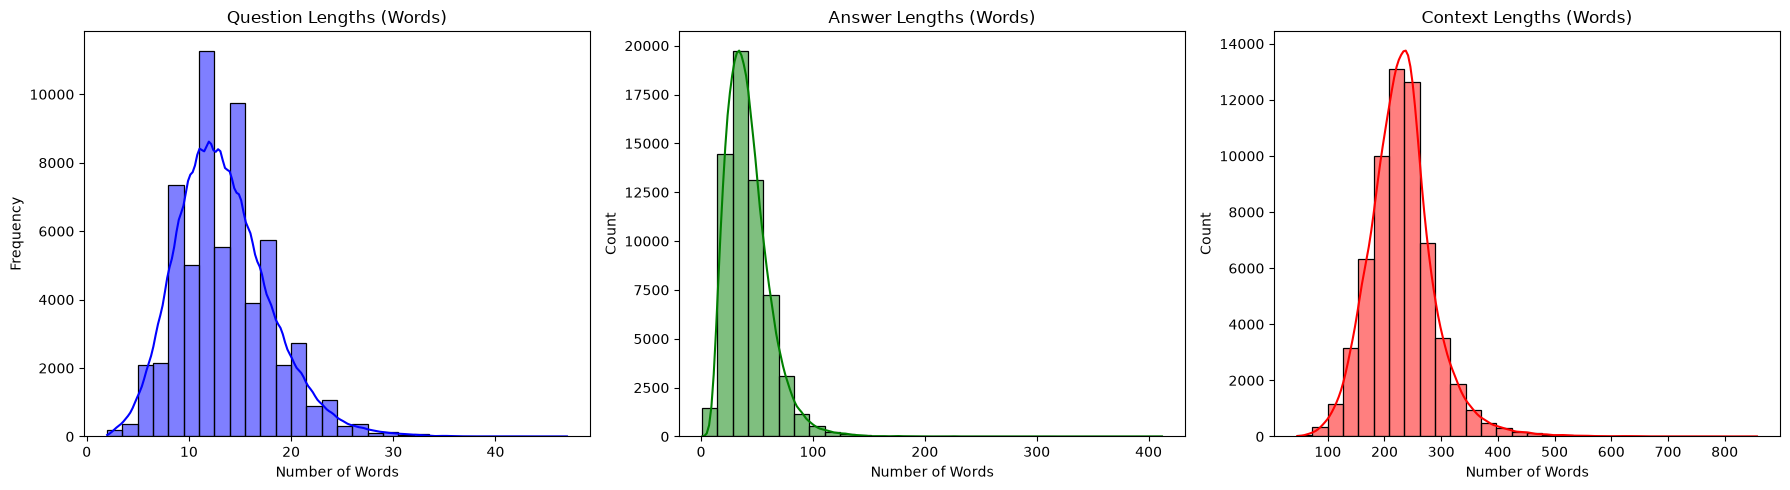

In [ ]:
# Statistics
plt.figure(figsize=(18, 5))

# Plot 1: Question Length Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['question_word_count'], bins=30, kde=True, color='blue')
plt.title('Question Lengths (Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
# Plot 2: Answer Length Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['answer_word_count'], bins=30, kde=True, color='green')
plt.title('Answer Lengths (Words)')
plt.xlabel('Number of Words')
# Plot 3: Context Length Distribution
plt.subplot(1, 3, 3)
sns.histplot(df['context_word_count'], bins=30, kde=True, color='red')
plt.title('Context Lengths (Words)')
plt.xlabel('Number of Words')
plt.tight_layout()
plt.show()


In [ ]:
print("Top 5 most common question type")
print(df['first_word'].value_counts().head(5))


print("\nTop 5 least common question type")
print(df['first_word'].value_counts().tail(5))

Top 5 most common question type
first_word
Is      10820
Does     9461
Do       4486
Can      4454
Are      3890
Name: count, dtype: int64

Top 5 least common question type
first_word
Jugular              1
Alcoholics'          1
Duodenojejunitis:    1
Pancreatitis         1
Diversion            1
Name: count, dtype: int64


## Bivariate & Multivariate Analysis 

                     question_word_count  context_word_count  \
question_word_count             1.000000            0.113691   
context_word_count              0.113691            1.000000   
answer_word_count               0.035288            0.146684   

                     answer_word_count  
question_word_count           0.035288  
context_word_count            0.146684  
answer_word_count             1.000000  


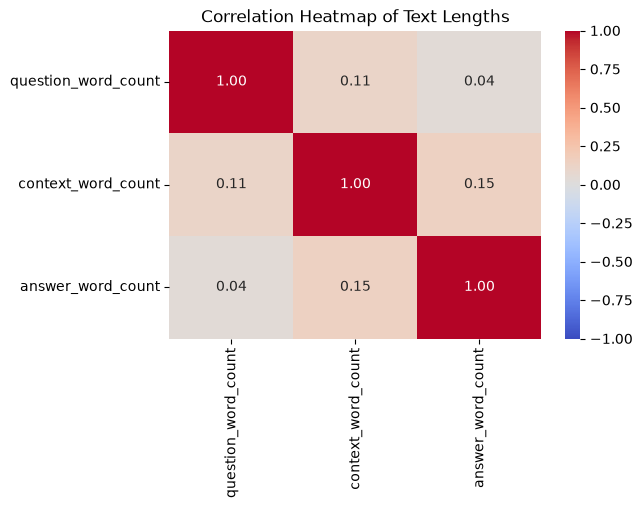

In [ ]:
# Correlation Matrix
correlation_matrix = df[['question_word_count', 'context_word_count', 'answer_word_count']].corr()
print(correlation_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Text Lengths')
plt.show()